In [2]:
# Cell 1: imports and display options

import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)


In [4]:

import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn import preprocessing
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [6]:
def evaluateBinaryClassification(predictions, actuals):
    contigency = pd.crosstab(actuals, predictions)

    print(contigency)  # 👈 always print to debug

    labels = contigency.index.tolist()

    TP = contigency.loc[labels[1], labels[1]]
    TN = contigency.loc[labels[0], labels[0]]
    FP = contigency.loc[labels[0], labels[1]]
    FN = contigency.loc[labels[1], labels[0]]

    print("TP:", TP, "TN:", TN, "FP:", FP, "FN:", FN)

In [8]:
import os
os.chdir('/Users/zolf/Desktop/T1')

In [10]:
df = pd.read_csv("ICU TOT.csv", sep=";", decimal=",")

In [12]:
print("Shape:", df.shape)
df.head()

Shape: (165, 42)


,ID,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI,ICU_Total1
0,1,"4,0",7,122,1,2,3,1,1,1,55,63,65,57,64,48,13,4,4,4,7,0,3,3,4,4,"27,27","19,82","15,82","27,74","22,60","216,85","229,38","262,78","243,70","308,48","31,31","23,27","19,98","29,42","27,68",22
1,2,"4,0",9,90,1,1,2,2,1,1,73,63,70,68,68,52,20,1,6,4,5,3,5,3,4,0,"52,90","52,15","73,61","75,76","58,88","127,23","215,43","221,03","160,28","168,73","54,45","50,27","76,11","73,37","61,44",14
2,3,"3,0",10,97,1,1,2,1,1,1,70,71,81,72,75,56,20,4,7,5,4,2,1,2,4,4,"34,40","17,11","44,34","44,71","29,29","190,65","188,25","195,35","165,10","189,10","35,74","15,79","43,01","40,00","26,80",12
3,4,"4,0",7,111,2,2,4,1,1,1,57,53,64,50,61,52,14,4,5,3,6,4,2,4,3,0,"51,83","46,88","55,83","42,92","44,06","152,20","154,30","156,35","133,38","235,65","51,62","43,47","50,55","47,68","44,38",12
4,5,"3,0",9,100,1,1,3,1,1,1,82,64,70,75,70,52,11,4,5,2,5,4,3,3,4,3,"45,20","16,67","44,83","19,52","19,29","161,03","68,85","164,93","80,20","94,05","46,86","15,98","45,78","17,79","19,04",45


In [14]:
# Cell 3: clean column names 

# strip leading/trailing spaces and remove internal spaces
df.columns = df.columns.str.strip().str.replace(r"\s+", "", regex=True)

print("Column names after cleaning:")
print(df.columns.tolist())


Column names after cleaning:
['ID', 'MAOAuVNTR', 'Eta', 'QI', 'adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical', 'AD', 'RBB', 'AB', 'TOTINT', 'TOTEXT', 'APQ_POS', 'APQ_NEG', 'APSD_CU', 'APSD_IMP', 'APSD_NARCI', 'Sintomi_DOP', 'ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto', 'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI', 'ICU_Total1']


In [16]:
# Cell 4: replace weird placeholders with NaN

placeholders = ['#NULL!', 'NULL', 'NaN', 'NA', 'n/a', 'N/A', ' ', '']
df = df.replace(placeholders, np.nan)

print("Done replacing placeholders. Any NaNs now:", df.isna().sum().sum())


Done replacing placeholders. Any NaNs now: 846


In [18]:
# Cell 5: fix numeric-like columns (commas, percents)

for col in df.columns:
    s = df[col].astype(str)

    # If there are % values → remove % and convert comma to dot
    if s.str.contains('%').any():
        s = s.str.replace('%', '', regex=False).str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')
    
    # Else, if there are commas but no % → treat as decimal comma
    elif s.str.contains(',').any():
        s = s.str.replace(',', '.', regex=False)
        df[col] = pd.to_numeric(s, errors='coerce')

    # Otherwise, try numeric conversion but don't force
    else:
        try:
            df[col] = pd.to_numeric(df[col], errors='ignore')
        except Exception:
            pass

print("Dtypes after numeric cleaning:")
print(df.dtypes)


Dtypes after numeric cleaning:
ID                int64
MAOAuVNTR       float64
Eta             float64
QI              float64
adhd            float64
farmaco         float64
cse             float64
emotional       float64
neglect         float64
physical        float64
AD                int64
RBB               int64
AB                int64
TOTINT            int64
TOTEXT            int64
APQ_POS         float64
APQ_NEG         float64
APSD_CU           int64
APSD_IMP          int64
APSD_NARCI        int64
Sintomi_DOP     float64
ER_paura        float64
ER_tristezza    float64
ER_rabbia       float64
ER_felicità     float64
ER_disgusto     float64
FC_E_AN         float64
FC_E_HA         float64
FC_E_SA         float64
FC_E_FE         float64
FC_E_DI         float64
FFD_E_AN        float64
FFD_E_HA        float64
FFD_E_SA        float64
FFD_E_FE        float64
FFD_E_DI        float64
FD_E_AN         float64
FD_E_HA         float64
FD_E_SA         float64
FD_E_FE         float64
FD_E_DI  

In [20]:
# Cell 6: define column groups

# main continuous targets
target_cont = ['ICU_Total1']

# gene variant (categorical)
gene_vars = ['MAOAuVNTR']

# categorical clinical-like variables
class_vars = ['adhd', 'farmaco', 'cse', 'emotional', 'neglect', 'physical']

# eye-tracking metrics
eye_tracking_vars = [
    'FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI',
    'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI',
    'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI'
]

# emotion recognition variables
er_cols = ['ER_paura', 'ER_tristezza', 'ER_rabbia', 'ER_felicità', 'ER_disgusto']

# other numeric-like vars you mentioned
other_numeric = ['Eta', 'QI', 'APQ_POS', 'APQ_NEG', 'Sintomi_DOP']

print("Targets:", target_cont)
print("Eye-tracking vars:", eye_tracking_vars)


Targets: ['ICU_Total1']
Eye-tracking vars: ['FC_E_AN', 'FC_E_HA', 'FC_E_SA', 'FC_E_FE', 'FC_E_DI', 'FFD_E_AN', 'FFD_E_HA', 'FFD_E_SA', 'FFD_E_FE', 'FFD_E_DI', 'FD_E_AN', 'FD_E_HA', 'FD_E_SA', 'FD_E_FE', 'FD_E_DI']


In [22]:
# Cell 7: ensure numeric where expected

numeric_like = target_cont + eye_tracking_vars + er_cols + other_numeric

for col in numeric_like:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Numeric-like columns converted. Sample dtypes:")
print(df[numeric_like].dtypes.dropna())


Numeric-like columns converted. Sample dtypes:
ICU_Total1      float64
FC_E_AN         float64
FC_E_HA         float64
FC_E_SA         float64
FC_E_FE         float64
FC_E_DI         float64
FFD_E_AN        float64
FFD_E_HA        float64
FFD_E_SA        float64
FFD_E_FE        float64
FFD_E_DI        float64
FD_E_AN         float64
FD_E_HA         float64
FD_E_SA         float64
FD_E_FE         float64
FD_E_DI         float64
ER_paura        float64
ER_tristezza    float64
ER_rabbia       float64
ER_felicità     float64
ER_disgusto     float64
Eta             float64
QI              float64
APQ_POS         float64
APQ_NEG         float64
Sintomi_DOP     float64
dtype: object


In [24]:
# Cell 8: handle missing values

# numeric columns
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# categorical / object columns
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Total missing values after filling:", df.isna().sum().sum())


Total missing values after filling: 0


In [26]:
# Cell 9: create binary targets from continuous targets

for col in target_cont:
    if col in df.columns:
        median_val = df[col].median()
        df[col + '_binary'] = (df[col] > median_val).astype(int)
        print(f"{col}: median = {median_val:.3f}")

print("\nBinary target columns created:")
print([c for c in df.columns if c.endswith('_binary')])


ICU_Total1: median = 16.000

Binary target columns created:
['ICU_Total1_binary']


In [28]:
# Cell 10: check distributions of binary targets

binary_targets = [c for c in df.columns if c.endswith('_binary')]
for col in binary_targets:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())



ICU_Total1_binary value counts:
ICU_Total1_binary
0    108
1     57
Name: count, dtype: int64


In [30]:
# Cell 11: build X and y_clf (features and classification targets)

target_bin = [c for c in df.columns if c.endswith('_binary')]
all_targets = target_cont + target_bin

# ID-like columns to exclude if present
id_like = ['ID', 'Nome', 'Unnamed:0', 'Unnamed:1']

exclude_cols = all_targets + id_like
feature_cols = [c for c in df.columns if c not in exclude_cols]

X = df[feature_cols].copy()
y = df[target_bin].copy()

print("Feature columns:", len(feature_cols))
print("Classification targets:", target_bin)


Feature columns: 40
Classification targets: ['ICU_Total1_binary']


In [32]:
from sklearn.model_selection import train_test_split

# First split: train+val vs test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=1
)

# Second split: train vs validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=1
)
# 60% train, 20% val, 20% test

# Convert to 1D
y_train_1d = y_train.iloc[:, 0]
y_val_1d   = y_val.iloc[:, 0]
y_test_1d  = y_test.iloc[:, 0]

In [34]:
from sklearn.neural_network import MLPClassifier
import warnings

warnings.filterwarnings("ignore")

In [36]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neural_network import MLPClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(random_state=5))
])

param_grid = {
    'mlp__hidden_layer_sizes': [(5,), (10,), (20,), (10,5), (20,10)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__solver': ['adam'],
    'mlp__alpha': [0.0001, 0.001, 0.01],
    'mlp__learning_rate_init': [0.0001, 0.001, 0.01],
    'mlp__max_iter': [500],
    'mlp__early_stopping': [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

gridSearch = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    verbose=2
)

gridSearch.fit(X_train, y_train_1d)

best_model = gridSearch.best_estimator_

Fitting 5 folds for each of 90 candidates, totalling 450 fits


In [38]:
import numpy as np
from sklearn.metrics import f1_score

y_val_prob = best_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

best_t = 0.5
best_f1 = 0

for t in thresholds:
    y_val_pred = (y_val_prob > t).astype(int)
    f1 = f1_score(y_val_1d, y_val_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print("Best threshold:", best_t)
print("Validation F1:", best_f1)

Best threshold: 0.25000000000000006
Validation F1: 0.7407407407407408


In [40]:
from sklearn.metrics import classification_report

y_test_prob = best_model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_prob > best_t).astype(int)

print(classification_report(y_test_1d, y_test_pred))

              precision    recall  f1-score   support

           0       0.71      0.45      0.56        22
           1       0.37      0.64      0.47        11

    accuracy                           0.52        33
   macro avg       0.54      0.55      0.51        33
weighted avg       0.60      0.52      0.53        33



In [134]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)
best_f1 = 0
best_t = 0.5

for t in thresholds:
    y_pred = (y_prob > t).astype(int)
    f1 = f1_score(y_test_1d, y_pred)
    
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(best_t, best_f1)

0.7000000000000002 0.4444444444444445


In [130]:
def evaluateBinaryClassification(predictions, actuals):
    contingency = pd.crosstab(actuals, predictions)

    for val in [0, 1]:
        if val not in contingency.index:
            contingency.loc[val] = 0
        if val not in contingency.columns:
            contingency[val] = 0

    contingency = contingency.sort_index().sort_index(axis=1)

    TN = contingency.loc[0, 0]
    FP = contingency.loc[0, 1]
    FN = contingency.loc[1, 0]
    TP = contingency.loc[1, 1]

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print("Confusion Matrix:\n", contingency)
    print(f"\nTP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")
    print(f"\nAccuracy: {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")

    return TP, TN, FP, FN, accuracy, precision, recall, f1

In [132]:
y_pred = best_model.predict(X_test)

TP, TN, FP, FN, acc, prec, rec, f1 = evaluateBinaryClassification(y_pred, y_test_1d)

Confusion Matrix:
 col_0               0  1
ICU_Total1_binary       
0                  17  6
1                   6  4

TP: 4, TN: 17, FP: 6, FN: 6

Accuracy: 0.636
Precision: 0.400
Recall: 0.400
F1-score: 0.400


In [138]:
X.describe()

,MAOAuVNTR,Eta,QI,adhd,farmaco,cse,emotional,neglect,physical,AD,RBB,AB,TOTINT,TOTEXT,APQ_POS,APQ_NEG,APSD_CU,APSD_IMP,APSD_NARCI,Sintomi_DOP,ER_paura,ER_tristezza,ER_rabbia,ER_felicità,ER_disgusto,FC_E_AN,FC_E_HA,FC_E_SA,FC_E_FE,FC_E_DI,FFD_E_AN,FFD_E_HA,FFD_E_SA,FFD_E_FE,FFD_E_DI,FD_E_AN,FD_E_HA,FD_E_SA,FD_E_FE,FD_E_DI
count,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000,165.000000
mean,3.724242,9.539394,98.309091,1.666667,1.745455,2.751515,1.545455,1.200000,1.181818,63.660606,63.345455,67.545455,63.296970,66.363636,57.200000,20.321212,4.636364,5.618182,5.672727,5.321212,2.109091,2.200000,2.884848,3.509091,2.248485,55.347273,51.816667,53.276788,56.497333,45.812121,167.146909,171.363152,173.846667,172.599030,162.498848,56.909091,51.813030,55.234242,58.290606,46.370909
std,0.456678,1.816244,9.053781,0.472840,1.658881,0.578118,0.666759,0.457991,0.431570,6.272760,5.876425,6.799798,5.604032,5.510623,8.157146,5.641730,2.158621,1.849432,2.696347,1.427038,1.070777,1.037116,0.776217,0.808629,1.032438,19.335368,18.177270,23.342366,20.086987,18.424498,64.015958,69.722278,67.834648,64.549145,71.627372,21.767055,19.306331,26.653824,21.381443,18.914989
min,2.000000,7.000000,77.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,50.000000,50.000000,51.000000,41.000000,46.000000,40.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.500000,0.000000,6.250000,6.630000,0.000000,27.100000,0.000000,16.900000,41.880000,0.000000,6.000000,0.000000,6.960000,8.000000,0.000000
25%,3.000000,8.000000,93.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,60.000000,60.000000,63.000000,60.000000,63.000000,52.000000,16.000000,3.000000,4.000000,4.000000,4.000000,2.000000,2.000000,3.000000,3.000000,2.000000,44.000000,45.000000,39.110000,44.790000,34.900000,127.230000,139.750000,134.780000,137.580000,125.800000,45.040000,45.000000,41.540000,47.680000,35.960000
50%,4.000000,9.000000,98.000000,2.000000,2.000000,3.000000,1.000000,1.000000,1.000000,63.000000,63.000000,65.000000,63.000000,65.000000,56.000000,20.000000,4.000000,6.000000,5.000000,5.000000,2.000000,2.000000,3.000000,4.000000,2.000000,56.470000,54.000000,52.950000,59.380000,47.310000,160.000000,162.760000,165.380000,159.300000,148.830000,58.760000,52.000000,55.310000,61.490000,47.250000
75%,4.000000,10.000000,104.000000,2.000000,2.000000,3.000000,2.000000,1.000000,1.000000,69.000000,67.000000,70.000000,67.000000,70.000000,62.000000,25.000000,6.000000,7.000000,7.000000,6.000000,3.000000,3.000000,3.000000,4.000000,3.000000,65.830000,61.470000,67.860000,69.000000,55.310000,191.850000,202.000000,205.850000,197.330000,185.480000,68.260000,63.280000,71.220000,72.000000,56.720000
max,4.000000,16.000000,130.000000,2.000000,22.000000,4.000000,3.000000,3.000000,3.000000,84.000000,87.000000,92.000000,76.000000,87.000000,79.000000,35.000000,11.000000,10.000000,13.000000,8.000000,4.000000,5.000000,4.000000,4.000000,4.000000,100.000000,100.000000,146.460000,100.000000,100.000000,401.230000,430.500000,411.900000,397.900000,442.280000,167.000000,100.000000,189.100000,100.000000,100.000000


AUC: 0.6900826446280991


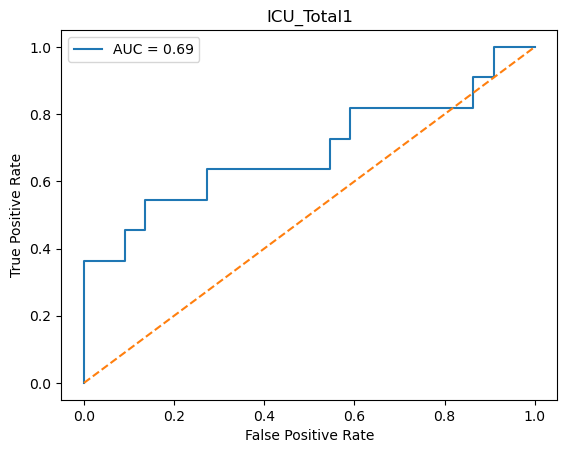

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probabilities
y_prob = best_model.predict_proba(X_test)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test_1d, y_prob)

# Compute AUC
auc_score = roc_auc_score(y_test_1d, y_prob)

print("AUC:", auc_score)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ICU_Total1')
plt.legend()

plt.show()